<a href="https://colab.research.google.com/github/Karima-mtq/Basemap/blob/main/projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
!ls

drive  grid.nc	sample_data


In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 47.0 MB/s eta 0:00:00


In [3]:
!pip install netCDF4
!pip install eofs
!pip install Basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3


In [45]:
%matplotlib inline
import xarray as xr
import os
from scipy import signal
from netCDF4 import Dataset
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from netCDF4 import num2date
import numpy as np
import numpy.polynomial.polynomial as poly
import netCDF4 as netcdf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import glob

In [ ]:
grid = xr.open_dataset("/content/grid(5).nc")
print(grid)

<xarray.Dataset> Size: 67MB
Dimensions:  (y: 384, x: 320, nv: 4, pcomp: 86231, qcomp: 87976, ucomp: 88019,
              vcomp: 87567)
Coordinates:
  * pcomp    (pcomp) int32 345kB 641 642 643 849 ... 122511 122512 122513 122514
  * qcomp    (qcomp) int32 352kB 642 643 850 851 ... 122648 122832 122833 122834
  * ucomp    (ucomp) int32 352kB 641 642 643 644 ... 122512 122513 122514 122515
  * vcomp    (vcomp) int32 350kB 641 642 643 849 ... 122831 122832 122833 122834
Dimensions without coordinates: y, x, nv
Data variables: (12/53)
    insw     (y, x) int32 492kB ...
    jnsw     (y, x) int32 492kB ...
    ins      (y, x) int32 492kB ...
    jns      (y, x) int32 492kB ...
    inse     (y, x) int32 492kB ...
    jnse     (y, x) int32 492kB ...
    ...       ...
    vdepth   (y, x) float64 983kB ...
    pmask    (y, x) int32 492kB ...
    umask    (y, x) int32 492kB ...
    vmask    (y, x) int32 492kB ...
    qmask    (y, x) int32 492kB ...
    cplmask  (y, x) int32 492kB ...
Attributes:

In [71]:
# Download all .nc files from the folder
!wget -r -np -nH --cut-dirs=5 -A "*ODA_ens.micom.hm.2010*.nc" \
    -P /content/drive/MyDrive/ODA_OCN \
    https://ns9039k.web.sigma2.no/datapeak/lgarcia/initializations/ODA/reana/ocn/



--2025-12-28 22:45:30--  https://ns9039k.web.sigma2.no/datapeak/lgarcia/initializations/ODA/reana/ocn/
Resolving ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)... 158.36.102.245
Connecting to ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)|158.36.102.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘/content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp’

ocn/index.html.tmp      [  <=>               ]  86.14K   357KB/s    in 0.2s    

2025-12-28 22:45:31 (357 KB/s) - ‘/content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp’ saved [88211]

Loading robots.txt; please ignore errors.
--2025-12-28 22:45:31--  https://ns9039k.web.sigma2.no/robots.txt
Reusing existing connection to ns9039k.web.sigma2.no:443.
HTTP request sent, awaiting response... 404 Not Found
2025-12-28 22:45:31 ERROR 404: Not Found.

Removing /content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp since it should be rejected.

--2025-12-28 22:45:31--  https://ns9039k.web.sigma2.n

In [72]:
import glob
import xarray as xr
import numpy as np
from scipy.interpolate import griddata

all_files = sorted(glob.glob("/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.*.nc"))
files = [f for f in all_files if int(f.split('.')[-2].replace('-', '')) <= 201012]

ds_all = xr.open_mfdataset(
    files,
    combine="by_coords",
    engine="netcdf4",
    chunks={"time": 1}   # IMPORTANT pour la mémoire
)

sst = ds_all["sst"]   # (time, y, x)
print(sst.shape)


/tmp/ipython-input-1656190742.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(


(372, 384, 320)


In [80]:
# Extract the time values (cftime objects)
time_vals = ds_all['time'].values

# Get min and max years
year1 = min(t.year for t in time_vals)
year2 = max(t.year for t in time_vals)

print("Year range:", year1, "-", year2)

Year range: 1980 - 2010


In [81]:
sst_data = sst.values
nt,nlat,nlon = sst.shape
startY = year1
endY   = year2
ndy    = year2-year1+1
ny = nt/ndy

In [82]:
import numpy as np
import numpy.polynomial.polynomial as poly

# Dimensions
nt, nlat, nlon = sst_data.shape

sst_detrend = np.empty(sst_data.shape)
sst_coeffs  = np.empty((2, nlat, nlon))
sst_detrend[:,:,:] = np.nan

x = np.linspace(1, nt, nt)

for i in range(nlat):
    for j in range(nlon):
        y = sst_data[:, i, j]   # <-- use raw numpy array
        if np.all(np.isnan(y)):
            continue
        b = ~np.isnan(y)
        coefs = poly.polyfit(x[b], y[b], 1)
        sst_coeffs[0, i, j] = coefs[0]
        sst_coeffs[1, i, j] = coefs[1]
        ffit = poly.polyval(x[b], coefs)
        sst_detrend[b, i, j] = y[b] - ffit

In [83]:
sst_all = sst_detrend.reshape((ndy,int(ny),nlat,nlon), order='F').transpose((1,0,2,3)) # year, 36, lat, lon
sst_season = np.mean(sst_all, axis=0)
sst_diff = sst_all - sst_season
#mask_4d = np.broadcast_to((pmask_trimmed==0), sst_all.shape)
#sst_diff = np.ma.masked_array(sst_diff, mask=mask_4d) # have to do this, or fill in zeros in sst_diff.
sst_final = sst_diff.transpose((1,0,2,3)).reshape((ndy*int(ny),nlat,nlon), order='F')

In [84]:
sst_final.shape

(372, 384, 320)

In [103]:
grid = xr.open_dataset("/content/grid.nc")

lon = grid["plon"].values
lat = grid["plat"].values
pmask = grid["pmask"].values


In [104]:
lon_out = np.arange(-180, 181, 1)
lat_out = np.arange(-90, 91, 1)
lon_out_grid, lat_out_grid = np.meshgrid(lon_out, lat_out)

points = np.column_stack((lon.flatten(), lat.flatten()))
pmask_reg = griddata(
    points,
    pmask.flatten(),
    (lon_out_grid, lat_out_grid),
    method="nearest"   # IMPORTANT pour un masque
)

pmask_reg = np.where(pmask_reg >= 0.5, 1, 0)

In [87]:
def interp_2d(field_2d):
    values = field_2d.flatten()
    field_reg = griddata(
        points, values,
        (lon_out_grid, lat_out_grid),
        method="linear"
    )
    return field_reg




In [88]:
ntime = sst_final.shape[0]
sst_interp_list = []

for t in range(sst_final.shape[0]):
    print(f"Interpolating time step {t+1}/{sst_final.shape[0]}")

    field = sst_final[t, :, :]

    # Interpolation
    field_reg = interp_2d(field)

    # --- APPLIQUER LE MASQUE ICI ---
    field_reg[pmask_reg == 0] = np.nan

    sst_interp_list.append(field_reg)



Interpolating time step 1/372
Interpolating time step 2/372
Interpolating time step 3/372
Interpolating time step 4/372
Interpolating time step 5/372
Interpolating time step 6/372
Interpolating time step 7/372
Interpolating time step 8/372
Interpolating time step 9/372
Interpolating time step 10/372
Interpolating time step 11/372
Interpolating time step 12/372
Interpolating time step 13/372
Interpolating time step 14/372
Interpolating time step 15/372
Interpolating time step 16/372
Interpolating time step 17/372
Interpolating time step 18/372
Interpolating time step 19/372
Interpolating time step 20/372
Interpolating time step 21/372
Interpolating time step 22/372
Interpolating time step 23/372
Interpolating time step 24/372
Interpolating time step 25/372
Interpolating time step 26/372
Interpolating time step 27/372
Interpolating time step 28/372
Interpolating time step 29/372
Interpolating time step 30/372
Interpolating time step 31/372
Interpolating time step 32/372
Interpolating tim

In [96]:
sst_interp = xr.DataArray(
    data=np.array(sst_interp_list),
    dims=("time", "lat", "lon"),
    coords={
        "time": sst.time.values,
        "lat": lat_out,
        "lon": lon_out
    },
    name="sst"
)

print(sst_interp)


<xarray.DataArray 'sst' (time: 372, lat: 181, lon: 361)> Size: 194MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.0149729 , -0.01500225, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]

In [100]:
lat = lat_out  # de la grille interpolée
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]


In [101]:
from eofs.xarray import Eof

solver = Eof(sst_interp, weights=wgts)
eof1 = solver.eofs(neofs=10)
pc1  = solver.pcs(npcs=10, pcscaling=0)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()




In [106]:
parallels = np.arange(lat_out.min(), lat_out.max(), 30)
meridians = np.arange(lon_out.min(), lat_out.max(), 30)

In [ ]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Parallèles et méridiens
parallels  = np.arange(lat_out.min(), lat_out.max()+1, 30)   # ajouter +1 pour inclure le dernier
meridians = np.arange(lon_out.min(), lon_out.max()+1, 30)


for i in range(5):
    print(f"Plotting EOF {i+1}...")

    # EOF déjà sur la grille régulière
    eof_map = eof1[i, :, :]  # shape = (lat_out, lon_out)

    vmin = np.nanmin(eof_map)
    vmax = np.nanmax(eof_map)

    # ---- Figure ----
    fig = plt.figure(figsize=(9,9))

    # Carte EOF
    ax1 = fig.add_subplot(211, projection=ccrs.PlateCarree())
    im = ax1.pcolormesh(
        lon_out_grid, lat_out_grid, eof_map,
        cmap=plt.cm.RdBu_r,
        vmin=vmin, vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax1.add_feature(cfeature.LAND, facecolor="white")

    # Parallèles et méridiens
    gl = ax1.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = plt.FixedLocator(meridians)
    gl.ylocator = plt.FixedLocator(parallels)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Colorbar
    cbar = fig.colorbar(im, ax=ax1, orientation='vertical', fraction=0.05, pad=0.02)
    cbar.set_label("EOF amplitude", fontsize=12)
    ax1.set_title(f"EOF {i+1}", fontsize=16)

    # Subplot PC
    ax2 = fig.add_subplot(212)
    days = np.linspace(year1, year2, pc1.shape[0])
    ax2.plot(days, pc1[:, i], linewidth=2)
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_xlabel("Year")
    ax2.set_ylabel("PC amplitude")
    ax2.set_title(f"PC {i+1} time series")
    ax2.set_ylim(np.min(pc1.squeeze()), np.max(pc1.squeeze()))

    plt.tight_layout()
    plt.show()


In [64]:
print(varfrac.shape)   # doit afficher (10,)
print(lambdas.shape)   # doit afficher (10,)
varfrac10 = varfrac.data[:10]
lambdas10 = lambdas.data[:10]

(84,)
(84,)


In [107]:
ds_out = xr.Dataset(
    {
        "EOFs": (("mode", "lat", "lon"), eof1.data),
        "PCs" : (("time", "mode"), pc1.data),
        "variance_fraction": (("mode",), varfrac10.data),
        "eigenvalues": (("mode",), lambdas10.data)
    },
    coords={
        "mode": np.arange(1, eof1.shape[0]+1),
        "lat" : lat_out,
        "lon" : lon_out,
        "time": ds_all.time.values
    }
)

output_file = "/content/drive/MyDrive/EOFs_PCs_ODA_interpolated_1.nc"
ds_out.to_netcdf(output_file)
print(f"Fichier enregistré : {output_file}")


Fichier enregistré : /content/drive/MyDrive/EOFs_PCs_ODA_interpolated_1.nc


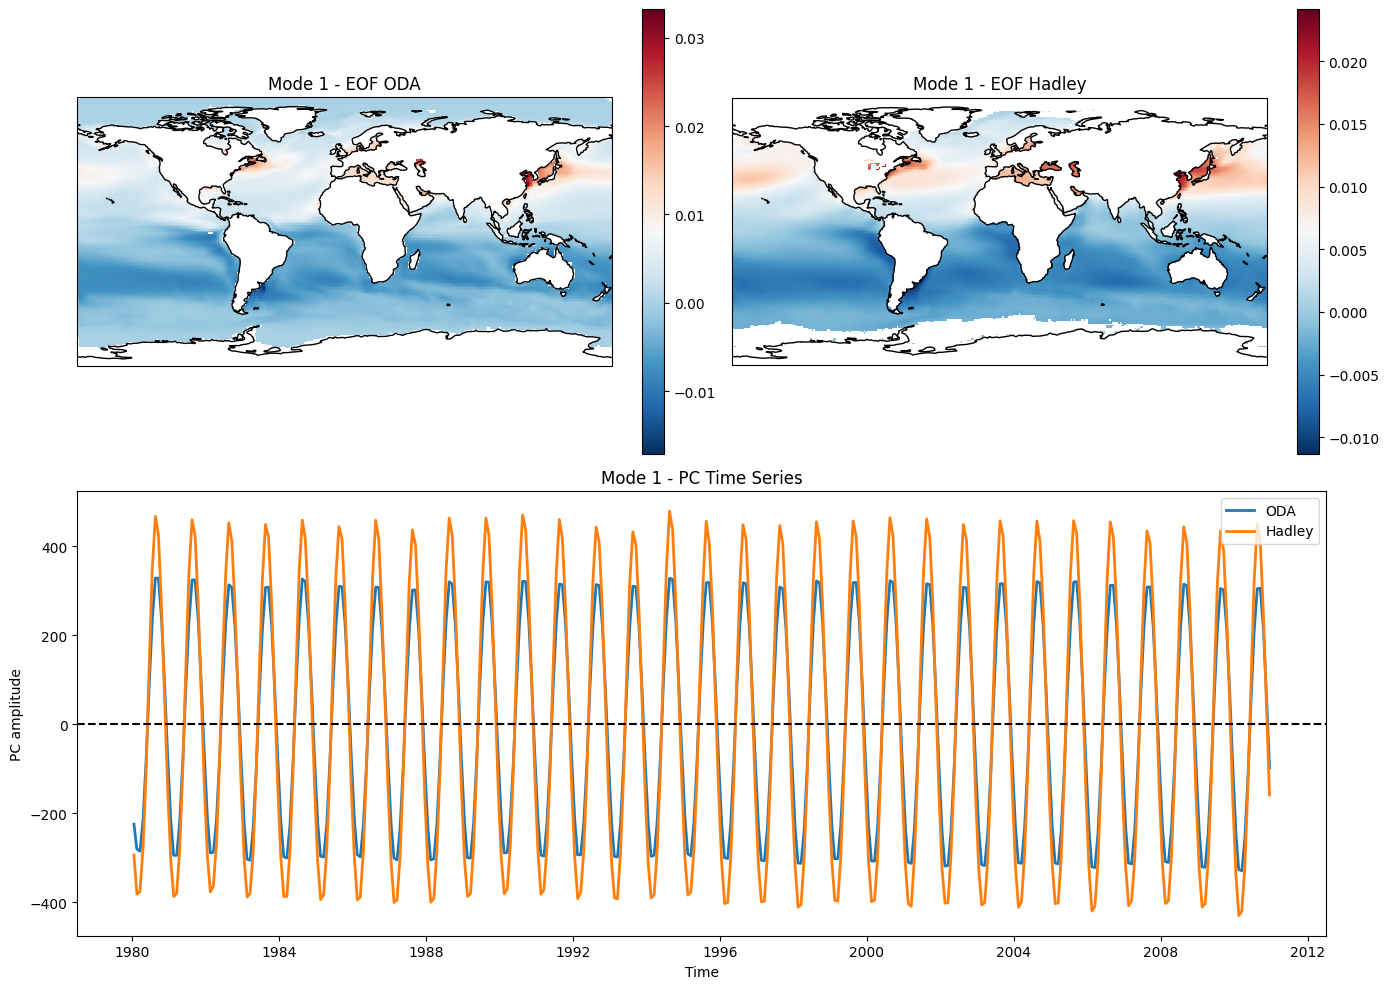

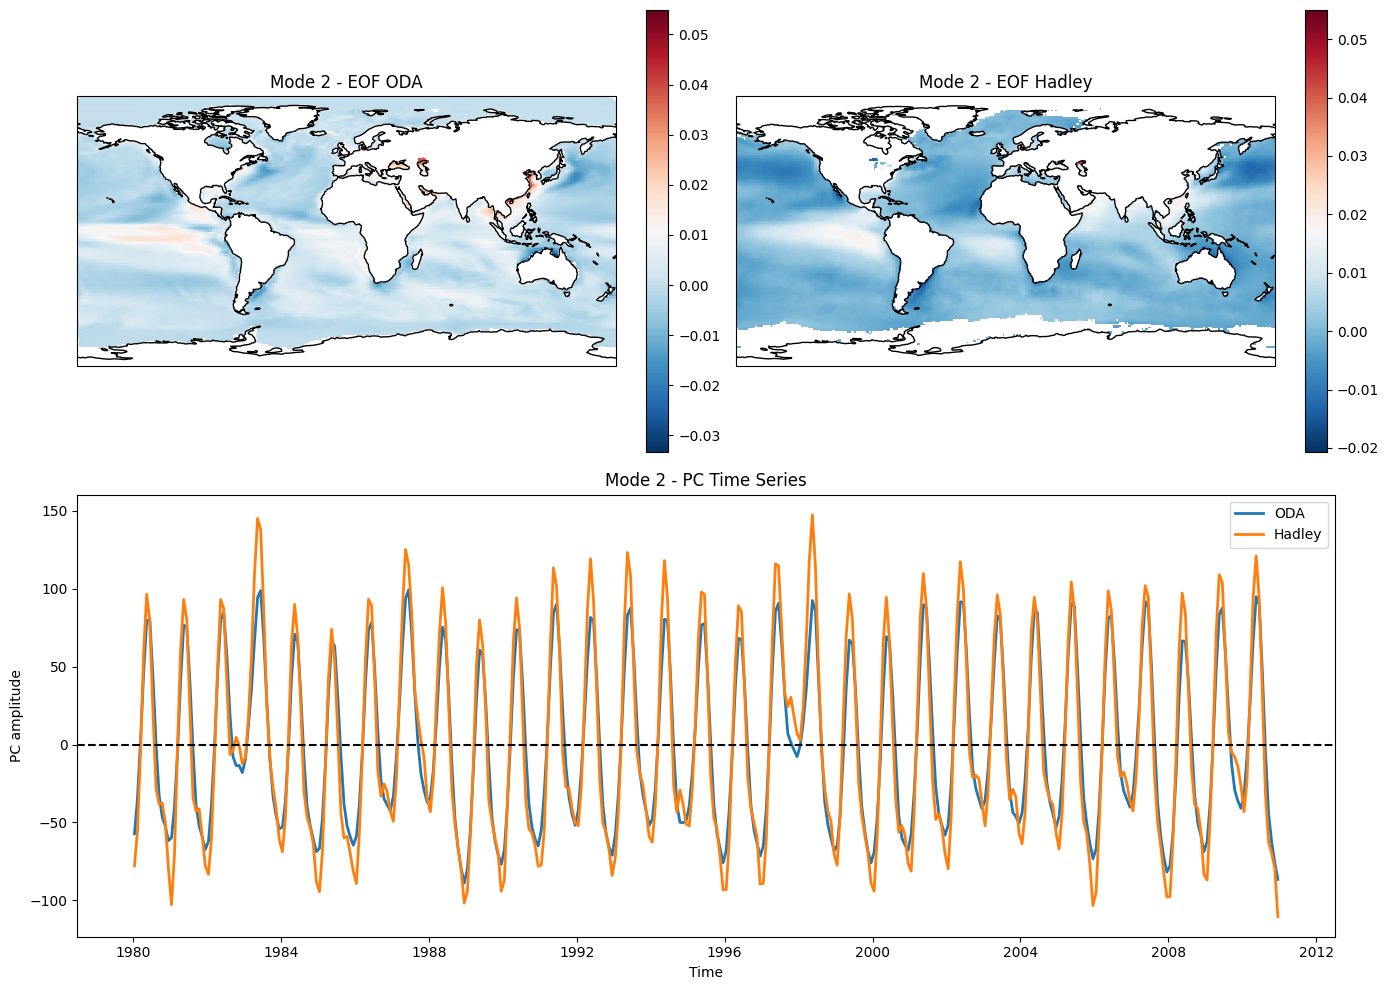

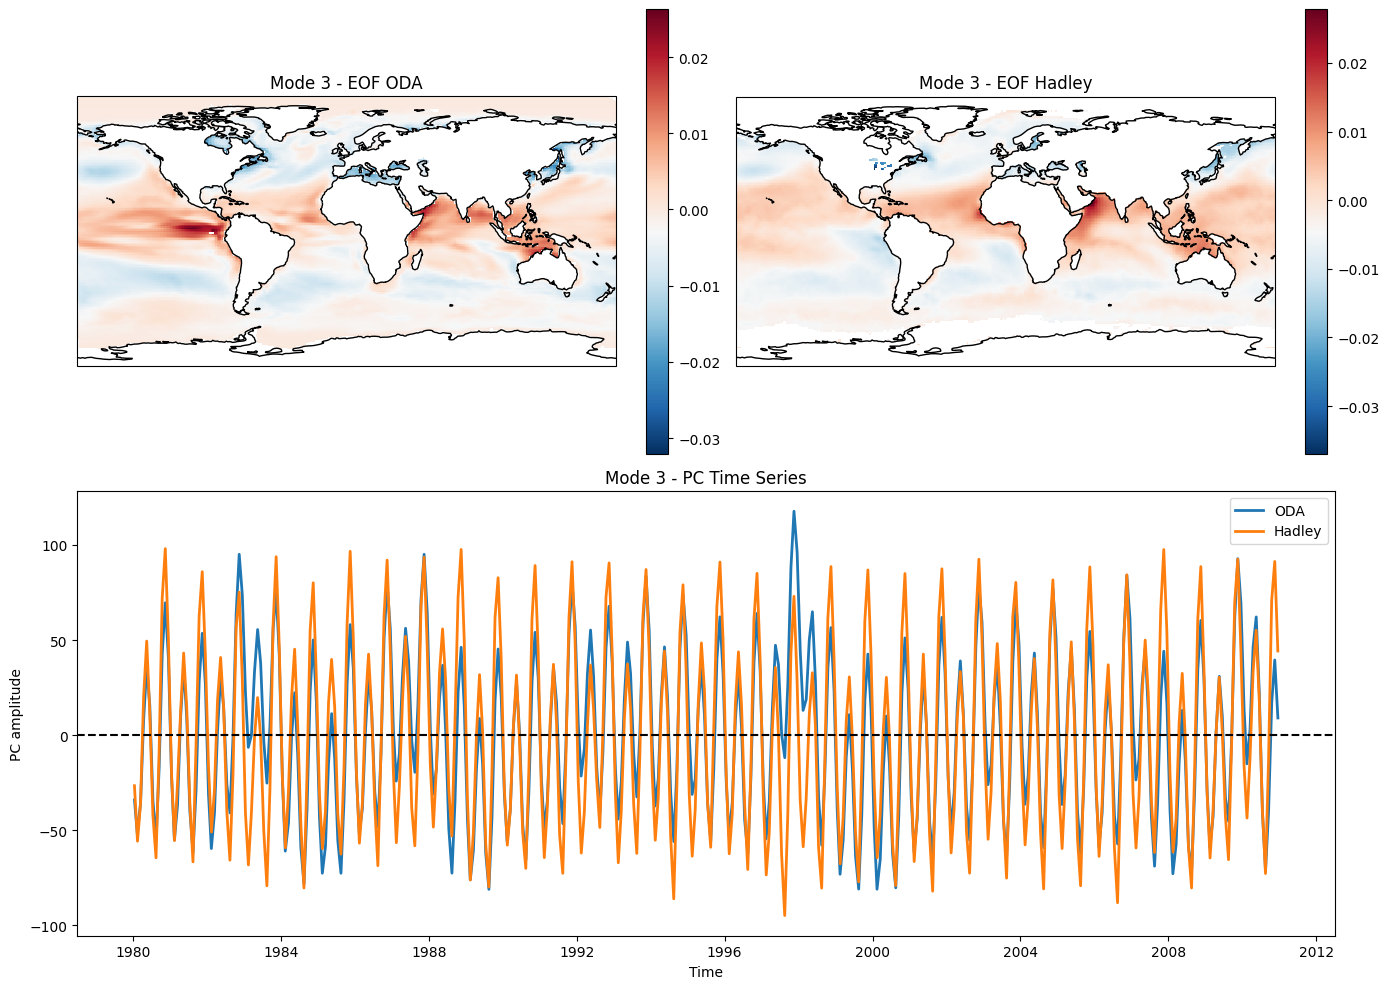

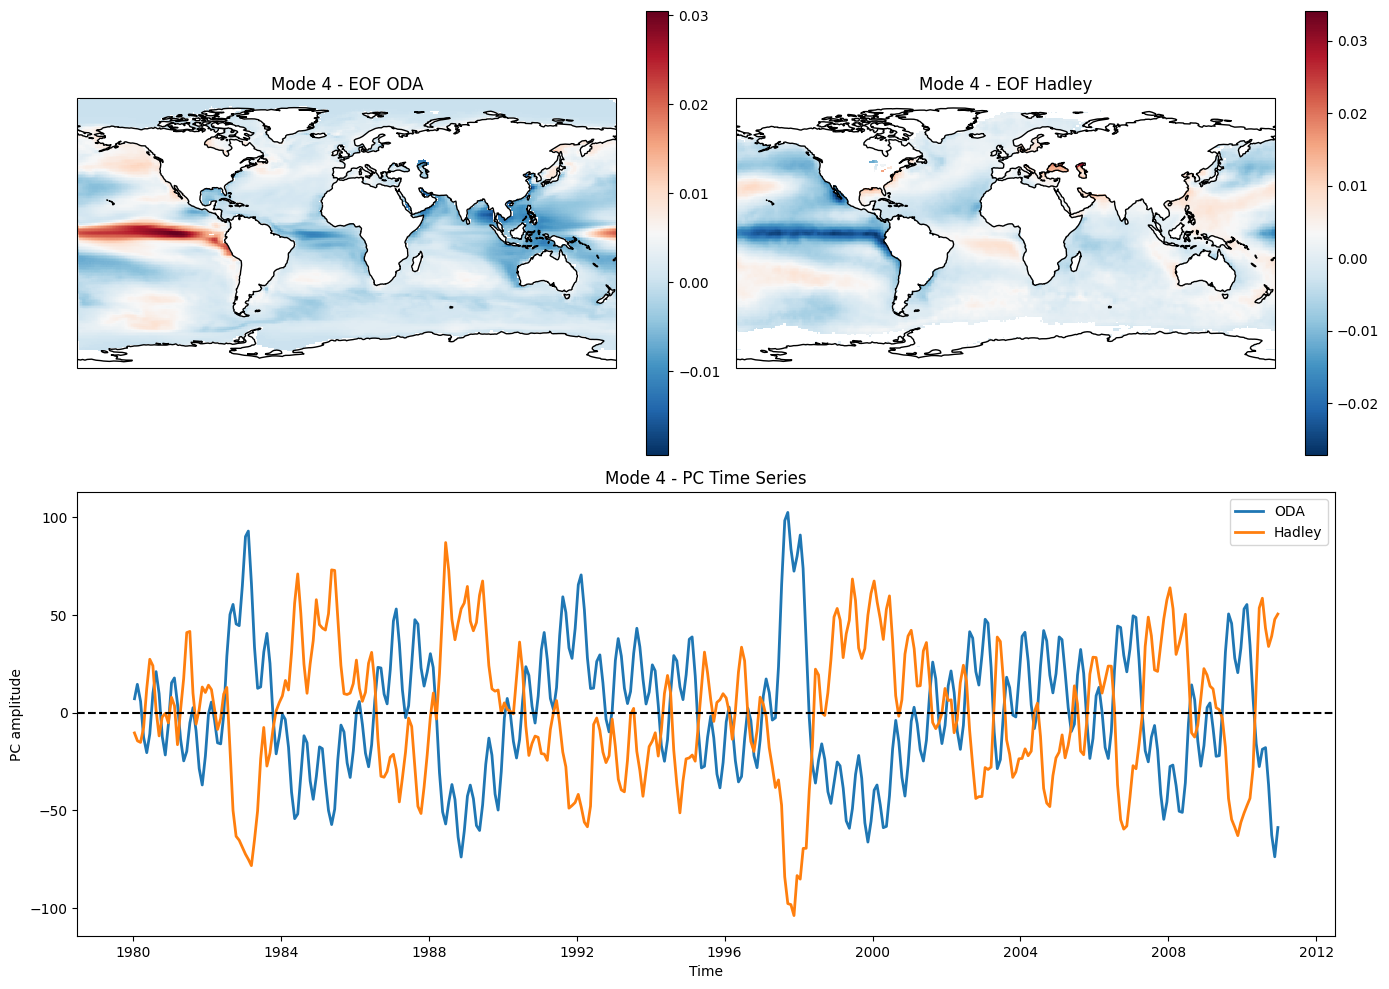

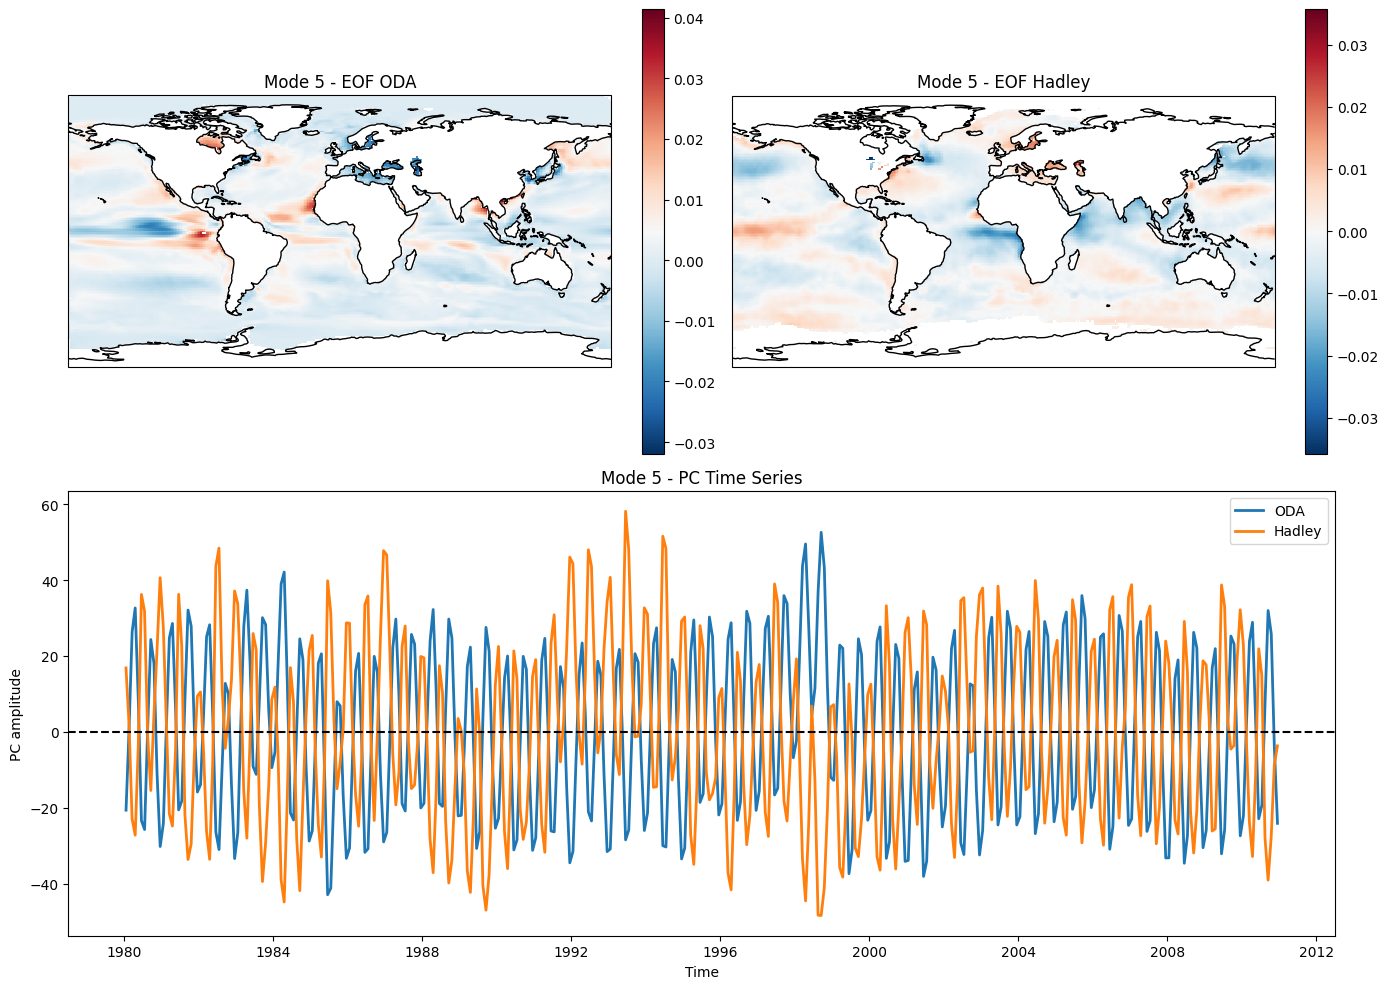

In [120]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import cftime

# --- 1. Load datasets ---
ds_oda = xr.open_dataset("/content/EOFs_PCs_ODA_interpolated_1.nc")
ds_had = xr.open_dataset("/content/EOFs_PCs_had_interpolated.nc")

# EOFs and PCs
eofs_oda = ds_oda["EOFs"].values
pcs_oda  = ds_oda["PCs"].values
lat_oda  = ds_oda["lat"].values
lon_oda  = ds_oda["lon"].values
time_oda = ds_oda["time"].values

eofs_had = ds_had["EOFs"].values
pcs_had  = ds_had["PCs"].values
lat_had  = ds_had["lat"].values
lon_had  = ds_had["lon"].values
time_had = ds_had["time"].values

# --- 2. Convert time ---
def convert_time(time_array):
    if isinstance(time_array[0], cftime.DatetimeNoLeap):
        return pd.to_datetime([t.strftime("%Y-%m-%d") for t in time_array])
    else:
        return pd.to_datetime(time_array)

time_oda_plot = convert_time(time_oda)
time_had_plot = convert_time(time_had)

# --- 3. Number of modes ---
nmodes = 5

# --- 4. Plot each mode EOFs side by side + PCs below ---
for i in range(nmodes):
    fig = plt.figure(figsize=(14,10))

    # --- EOFs ODA vs Hadley ---
    ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
    im1 = ax1.pcolormesh(lon_oda, lat_oda, eofs_oda[i,:,:],
                         cmap="RdBu_r", shading="auto",
                         transform=ccrs.PlateCarree())
    ax1.add_feature(cfeature.COASTLINE)
    ax1.add_feature(cfeature.LAND, facecolor="white")
    ax1.set_title(f"Mode {i+1} - EOF ODA")
    plt.colorbar(im1, ax=ax1, orientation="vertical", fraction=0.05)

    ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
    im2 = ax2.pcolormesh(lon_had, lat_had, eofs_had[i,:,:],
                         cmap="RdBu_r", shading="auto",
                         transform=ccrs.PlateCarree())
    ax2.add_feature(cfeature.COASTLINE)
    ax2.add_feature(cfeature.LAND, facecolor="white")
    ax2.set_title(f"Mode {i+1} - EOF Hadley")
    plt.colorbar(im2, ax=ax2, orientation="vertical", fraction=0.05)

    # --- PCs ODA vs Hadley ---
    ax3 = fig.add_subplot(2, 1, 2)
    ax3.plot(time_oda_plot, pcs_oda[:,i], label="ODA", linewidth=2)
    ax3.plot(time_had_plot, pcs_had[:,i], label="Hadley", linewidth=2)
    ax3.axhline(0, color='k', linestyle='--')
    ax3.set_xlabel("Time")
    ax3.set_ylabel("PC amplitude")
    ax3.set_title(f"Mode {i+1} - PC Time Series")
    ax3.legend()

    plt.tight_layout()
    plt.show()
